<a href="https://colab.research.google.com/github/mukeshk01/Financial-Literacy/blob/main/Financial_Literacy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Financial Literacy Simulator Plan

To create a financial literacy simulator, we can follow these steps:

1.  **Define the Simulation Scope**: What aspects of financial literacy will be covered? (e.g., budgeting, saving, investing, debt, income).
2.  **Initial Conditions**: Set up starting parameters for the player (e.g., initial cash, income, expenses, debt).
3.  **Core Game Loop**: Implement a time-based progression (e.g., monthly, annually) where events occur and decisions are made.
4.  **Events and Decisions**: Introduce random or structured events (e.g., unexpected expenses, investment opportunities, job changes) and allow the player to make financial decisions.
5.  **Track Progress**: Monitor key financial metrics over time (e.g., net worth, savings, debt-to-income ratio).
6.  **User Interface (Basic)**: Provide simple ways for the user to input decisions and view their financial status.
7.  **Visualization**: Plot financial progress over time to show the impact of decisions.
8.  **Refinement**: Add more complex scenarios, decision outcomes, and feedback.

Let's start by setting up some basic initial conditions and a way to track the player's financial status.

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML
import random # Import the random module

# --- 1. Initial Conditions ---

class FinancialSimulator:
    def __init__(self, initial_cash=1000, initial_income=2000, initial_expenses=1500, initial_debt=500,
                 debt_interest_rate=0.01, savings_interest_rate=0.001,
                 initial_investment=0, investment_return_rate=0.007):
        self.cash = initial_cash
        self.income = initial_income
        self.expenses = initial_expenses
        self.debt = initial_debt
        self.debt_interest_rate = debt_interest_rate # Monthly debt interest rate
        self.savings_interest_rate = savings_interest_rate # Monthly savings interest rate
        self.investment = initial_investment
        self.investment_return_rate = investment_return_rate # Monthly investment return rate
        self.net_worth = self.cash + self.investment - self.debt # Net worth includes investments
        self.month = 0

        # New: Goals tracking
        self.goals = {} # Stores {'goal_name': {'target_amount': X, 'target_month': Y, 'type': 'net_worth'}}
        self.goal_history = pd.DataFrame(columns=['Month']) # To store goal progress over time

        # History to track progress
        self.history = pd.DataFrame(columns=['Month', 'Cash', 'Income', 'Expenses', 'Debt', 'Investment', 'Net Worth'])
        self._record_state()

    def _record_state(self):
        new_row = {
            'Month': self.month,
            'Cash': self.cash,
            'Income': self.income,
            'Expenses': self.expenses,
            'Debt': self.debt,
            'Investment': self.investment,
            'Net Worth': self.net_worth
        }
        self.history = pd.concat([self.history, pd.DataFrame([new_row])], ignore_index=True)

        # Record goal progress as well
        goal_row = {'Month': self.month}
        for goal_name, goal_details in self.goals.items():
            if goal_details['type'] == 'net_worth':
                goal_row[f'{goal_name}_progress'] = self.net_worth
                goal_row[f'{goal_name}_target'] = goal_details['target_amount']
            elif goal_details['type'] == 'cash':
                goal_row[f'{goal_name}_progress'] = self.cash
                goal_row[f'{goal_name}_target'] = goal_details['target_amount']
            elif goal_details['type'] == 'investment':
                goal_row[f'{goal_name}_progress'] = self.investment
                goal_row[f'{goal_name}_target'] = goal_details['target_amount']

        if len(self.goals) > 0:
            self.goal_history = pd.concat([self.goal_history, pd.DataFrame([goal_row])], ignore_index=True)

    def set_goal(self, name, target_amount, target_month, goal_type='net_worth'):
        """Sets a financial goal."""
        if name in self.goals:
            print(f"Goal '{name}' already exists and will be updated.")
        self.goals[name] = {
            'target_amount': target_amount,
            'target_month': target_month,
            'type': goal_type, # e.g., 'net_worth', 'cash', 'investment'
            'status': 'In Progress' # Initial status
        }
        print(f"Goal '{name}' set: Target {goal_type} of ${target_amount:.2f} by Month {target_month}.")

    def update_goals(self):
        """Updates the status of all active goals."""
        for goal_name, goal_details in self.goals.items():
            if goal_details['status'] == 'In Progress' or goal_details['status'] == 'Achieved (Late)':
                current_value = 0
                if goal_details['type'] == 'net_worth':
                    current_value = self.net_worth
                elif goal_details['type'] == 'cash':
                    current_value = self.cash
                elif goal_details['type'] == 'investment':
                    current_value = self.investment

                if current_value >= goal_details['target_amount']:
                    if self.month <= goal_details['target_month']:
                        self.goals[goal_name]['status'] = 'Achieved'
                        print(f"  Goal '{goal_name}' ACHIEVED in Month {self.month} (Target Month: {goal_details['target_month']})!")
                    else:
                        self.goals[goal_name]['status'] = 'Achieved (Late)'
                        print(f"  Goal '{goal_name}' ACHIEVED LATE in Month {self.month} (Target Month: {goal_details['target_month']})!")
                elif self.month > goal_details['target_month'] and self.goals[goal_name]['status'] == 'In Progress': # Only mark as missed if still 'In Progress'
                    self.goals[goal_name]['status'] = 'Missed'
                    print(f"  Goal '{goal_name}' MISSED in Month {self.month} (Target Month: {goal_details['target_month']})!")

    def invest(self, amount):
        if self.cash >= amount:
            self.cash -= amount
            self.investment += amount
            print(f"  Invested {amount:.2f}. Current investment: {self.investment:.2f}")
        else:
            print(f"  Not enough cash to invest {amount:.2f}. Current cash: {self.cash:.2f}")

    def pay_debt(self, amount):
        if self.cash >= amount:
            self.cash -= amount
            self.debt -= amount
            if self.debt < 0: # Ensure debt doesn't go negative
                self.debt = 0
            print(f"  Paid {amount:.2f} towards debt. Current debt: {self.debt:.2f}")
        else:
            print(f"  Not enough cash to pay {amount:.2f} towards debt. Current cash: {self.cash:.2f}")

    def generate_random_event(self):
        event_type = random.choice(['expense', 'income', 'none'])
        if event_type == 'expense':
            amount = random.randint(50, 500)
            self.cash -= amount
            print(f"  Random Event: Unexpected expense of ${amount:.2f}")
        elif event_type == 'income':
            amount = random.randint(100, 700)
            self.cash += amount
            print(f"  Random Event: Bonus income of ${amount:.2f}")
        else:
            print("  Random Event: No special event this month.")

    def advance_month(self, invest_amount=0, pay_debt_amount=0):
        self.month += 1

        # Basic monthly operations (income - expenses)
        self.cash += self.income - self.expenses

        # Apply debt interest
        if self.debt > 0:
            debt_interest = self.debt * self.debt_interest_rate
            self.debt += debt_interest
            # print(f"  Debt interest applied: {debt_interest:.2f}") # For debugging

        # Apply savings interest (only if cash is positive)
        if self.cash > 0:
            savings_interest = self.cash * self.savings_interest_rate
            self.cash += savings_interest
            # print(f"  Savings interest applied: {savings_interest:.2f}") # For debugging

        # Apply investment returns
        if self.investment > 0:
            investment_gains = self.investment * self.investment_return_rate
            self.investment += investment_gains
            # print(f"  Investment gains: {investment_gains:.2f}") # For debugging

        # Generate a random event
        self.generate_random_event()

        # Apply decisions for the month
        if invest_amount > 0:
            self.invest(invest_amount)
        if pay_debt_amount > 0:
            self.pay_debt(pay_debt_amount)

        # Update net worth
        self.net_worth = self.cash + self.investment - self.debt

        # Update and check goals AFTER net worth is calculated
        self.update_goals()

        self._record_state()
        print(f"--- End of Month {self.month} ---")
        self.display_status()
        self.display_goals() # Display goals status after each month

    def display_status(self):
        status_df = pd.DataFrame({
            'Metric': ['Cash', 'Income', 'Expenses', 'Debt', 'Investment', 'Net Worth', 'Debt Interest Rate', 'Savings Interest Rate', 'Investment Return Rate'],
            'Value': [f"{self.cash:.2f}", f"{self.income:.2f}", f"{self.expenses:.2f}", f"{self.debt:.2f}", f"{self.investment:.2f}", f"{self.net_worth:.2f}", self.debt_interest_rate, self.savings_interest_rate, self.investment_return_rate]
        })
        display(HTML(status_df.to_html(index=False)))

    def display_goals(self):
        """Displays the current status of all financial goals."""
        if not self.goals:
            print("\n--- No Financial Goals Set ---")
            return
        goal_data = []
        for name, details in self.goals.items():
            current_value = 0
            if details['type'] == 'net_worth':
                current_value = self.net_worth
            elif details['type'] == 'cash':
                current_value = self.cash
            elif details['type'] == 'investment':
                current_value = self.investment

            goal_data.append({
                'Goal Name': name,
                'Type': details['type'],
                'Target Amount': f"${details['target_amount']:.2f}",
                'Current Value': f"${current_value:.2f}",
                'Target Month': details['target_month'],
                'Current Month': self.month,
                'Status': details['status']
            })
        goals_df = pd.DataFrame(goal_data)
        print("\n--- Financial Goals Status ---")
        display(HTML(goals_df.to_html(index=False)))


    def get_history(self):
        return self.history

    def get_goal_history(self):
        """Returns the history of goal progress."""
        return self.goal_history

print("Simulator class defined. We can now create an instance and run it.")


Simulator class defined. We can now create an instance and run it.


### Demonstrating Random Events, Investment, and Debt Payment Decisions

In [14]:
# Re-initialize the simulator with random events enabled
sim_with_random_events = FinancialSimulator(
    initial_cash=5000,
    initial_income=3000,
    initial_expenses=2000,
    initial_debt=2000,
    debt_interest_rate=0.015,
    savings_interest_rate=0.005,
    investment_return_rate=0.007
)

print("Initial Financial Status (with random events capability):")
sim_with_random_events.display_status()

print("\n--- Running Simulation with Random Events and Decisions ---\n")

# Run for 10 months, mixing decisions and letting random events occur
for month_num in range(1, 11):
    invest_amt = 0
    pay_debt_amt = 0

    if month_num % 3 == 1: # Every 3rd month (1, 4, 7, 10), invest
        invest_amt = 500
    elif month_num % 3 == 2: # Every 3rd month (2, 5, 8), pay debt
        pay_debt_amt = 300
    # Month 3, 6, 9 will have no explicit decision, just random events

    sim_with_random_events.advance_month(invest_amount=invest_amt, pay_debt_amount=pay_debt_amt)


Initial Financial Status (with random events capability):


Metric,Value
Cash,5000.00
Income,3000.00
Expenses,2000.00
Debt,2000.00
Investment,0.00
Net Worth,3000.00
Debt Interest Rate,0.015
Savings Interest Rate,0.005
Investment Return Rate,0.007



--- Running Simulation with Random Events and Decisions ---

  Random Event: No special event this month.
  Invested 500.00. Current investment: 500.00
--- End of Month 1 ---


Metric,Value
Cash,5530.00
Income,3000.00
Expenses,2000.00
Debt,2030.00
Investment,500.00
Net Worth,4000.00
Debt Interest Rate,0.015
Savings Interest Rate,0.005
Investment Return Rate,0.007


  Random Event: No special event this month.
  Paid 300.00 towards debt. Current debt: 1760.45
--- End of Month 2 ---


...

Metric,Value
Cash,11741.91
Income,3000.00
Expenses,2000.00
Debt,1311.25
Investment,1542.67
Net Worth,11973.33
Debt Interest Rate,0.015
Savings Interest Rate,0.005
Investment Return Rate,0.007


  Random Event: Unexpected expense of $164.00
--- End of Month 9 ---


Metric,Value
Cash,12641.62
Income,3000.00
Expenses,2000.00
Debt,1330.92
Investment,1553.47
Net Worth,12864.17
Debt Interest Rate,0.015
Savings Interest Rate,0.005
Investment Return Rate,0.007


  Random Event: Unexpected expense of $171.00
  Invested 500.00. Current investment: 2064.34
--- End of Month 10 ---


Metric,Value
Cash,13038.83
Income,3000.00
Expenses,2000.00
Debt,1350.88
Investment,2064.34
Net Worth,13752.29
Debt Interest Rate,0.015
Savings Interest Rate,0.005
Investment Return Rate,0.007


### Visualizing the financial history with Random Events, Investment, and Debt Payment Decisions

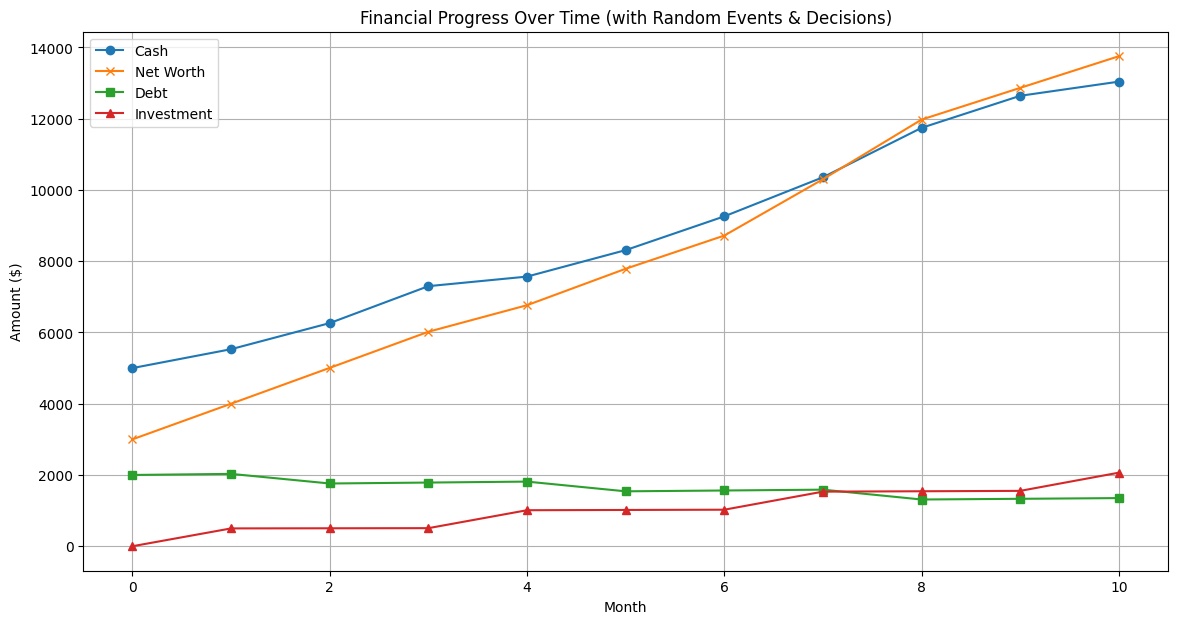

In [15]:
history_df_with_random_events = sim_with_random_events.get_history()

plt.figure(figsize=(14, 7))
plt.plot(history_df_with_random_events['Month'], history_df_with_random_events['Cash'], label='Cash', marker='o')
plt.plot(history_df_with_random_events['Month'], history_df_with_random_events['Net Worth'], label='Net Worth', marker='x')
plt.plot(history_df_with_random_events['Month'], history_df_with_random_events['Debt'], label='Debt', marker='s')
plt.plot(history_df_with_random_events['Month'], history_df_with_random_events['Investment'], label='Investment', marker='^')
plt.title('Financial Progress Over Time (with Random Events & Decisions)')
plt.xlabel('Month')
plt.ylabel('Amount ($)')
plt.grid(True)
plt.legend()
plt.show()


### Demonstrating Financial Goal Tracking

In [17]:
# Re-initialize the simulator to incorporate goal tracking
sim_with_goals = FinancialSimulator(
    initial_cash=5000,
    initial_income=3000,
    initial_expenses=2000,
    initial_debt=2000,
    debt_interest_rate=0.015,
    savings_interest_rate=0.005,
    investment_return_rate=0.007
)

print("Initial Financial Status (with goals capability):")
sim_with_goals.display_status()

# Set some financial goals
sim_with_goals.set_goal(name='Net Worth Target 10k', target_amount=10000, target_month=8, goal_type='net_worth')
sim_with_goals.set_goal(name='Investment Target 2.5k', target_amount=2500, target_month=12, goal_type='investment')
sim_with_goals.set_goal(name='Cash Target 15k', target_amount=15000, target_month=15, goal_type='cash')

print("\n--- Running Simulation with Goals and Decisions ---\n")

# Run for 15 months, mixing decisions and letting random events occur
for month_num in range(1, 16):
    invest_amt = 0
    pay_debt_amt = 0

    if month_num % 3 == 1: # Every 3rd month (1, 4, 7, 10, 13), invest
        invest_amt = 500
    elif month_num % 3 == 2: # Every 3rd month (2, 5, 8, 11, 14), pay debt
        pay_debt_amt = 300
    # Month 3, 6, 9, 12, 15 will have no explicit decision, just random events

    sim_with_goals.advance_month(invest_amount=invest_amt, pay_debt_amount=pay_debt_amt)


Initial Financial Status (with goals capability):


Metric,Value
Cash,5000.00
Income,3000.00
Expenses,2000.00
Debt,2000.00
Investment,0.00
Net Worth,3000.00
Debt Interest Rate,0.015
Savings Interest Rate,0.005
Investment Return Rate,0.007


Goal 'Net Worth Target 10k' set: Target net_worth of $10000.00 by Month 8.
Goal 'Investment Target 2.5k' set: Target investment of $2500.00 by Month 12.
Goal 'Cash Target 15k' set: Target cash of $15000.00 by Month 15.

--- Running Simulation with Goals and Decisions ---

  Random Event: Unexpected expense of $116.00
  Invested 500.00. Current investment: 500.00
--- End of Month 1 ---


Metric,Value
Cash,5414.00
Income,3000.00
Expenses,2000.00
Debt,2030.00
Investment,500.00
Net Worth,3884.00
Debt Interest Rate,0.015
Savings Interest Rate,0.005
Investment Return Rate,0.007



--- Financial Goals Status ---


...

Goal Name,Type,Target Amount,Current Value,Target Month,Current Month,Status
Net Worth Target 10k,net_worth,$10000.00,$18688.83,8,14,Achieved
Investment Target 2.5k,investment,$2500.00,$2626.25,12,14,Achieved (Late)
Cash Target 15k,cash,$15000.00,$16882.65,15,14,Achieved


  Random Event: No special event this month.
  Goal 'Investment Target 2.5k' ACHIEVED LATE in Month 15 (Target Month: 12)!
--- End of Month 15 ---


Metric,Value
Cash,17972.07
Income,3000.00
Expenses,2000.00
Debt,832.37
Investment,2644.64
Net Worth,19784.33
Debt Interest Rate,0.015
Savings Interest Rate,0.005
Investment Return Rate,0.007



--- Financial Goals Status ---


Goal Name,Type,Target Amount,Current Value,Target Month,Current Month,Status
Net Worth Target 10k,net_worth,$10000.00,$19784.33,8,15,Achieved
Investment Target 2.5k,investment,$2500.00,$2644.64,12,15,Achieved (Late)
Cash Target 15k,cash,$15000.00,$17972.07,15,15,Achieved


### Visualizing Goal Progress and Financial History

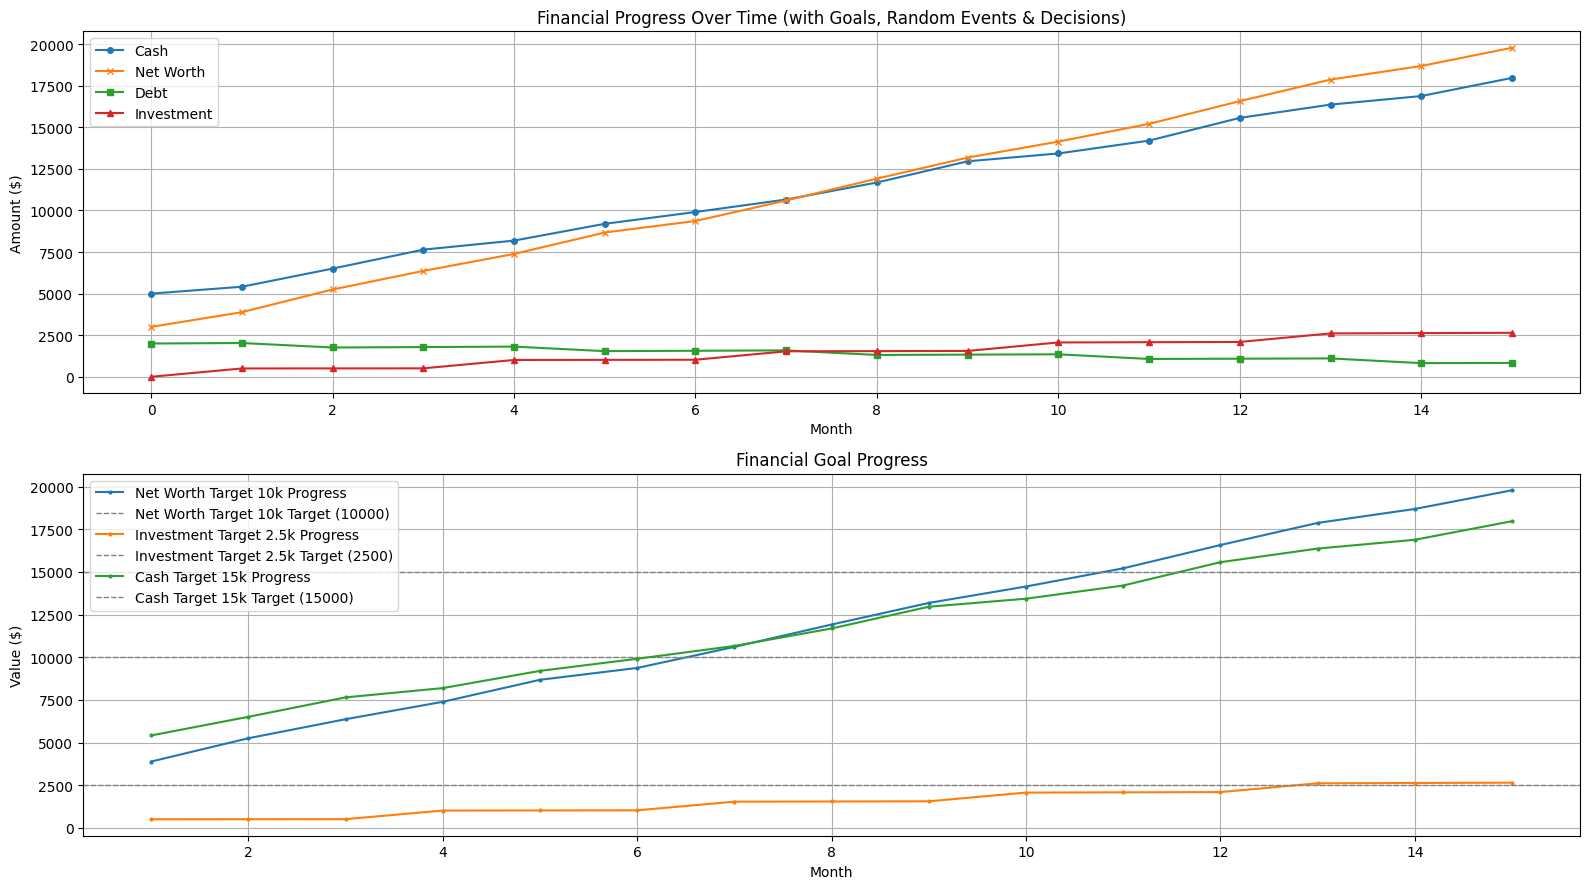

In [18]:
history_df_with_goals = sim_with_goals.get_history()
goal_history_df = sim_with_goals.get_goal_history()

plt.figure(figsize=(16, 9))

# Plot financial metrics
plt.subplot(2, 1, 1) # Two rows, one column, first plot
plt.plot(history_df_with_goals['Month'], history_df_with_goals['Cash'], label='Cash', marker='o', markersize=4)
plt.plot(history_df_with_goals['Month'], history_df_with_goals['Net Worth'], label='Net Worth', marker='x', markersize=4)
plt.plot(history_df_with_goals['Month'], history_df_with_goals['Debt'], label='Debt', marker='s', markersize=4)
plt.plot(history_df_with_goals['Month'], history_df_with_goals['Investment'], label='Investment', marker='^', markersize=4)
plt.title('Financial Progress Over Time (with Goals, Random Events & Decisions)')
plt.xlabel('Month')
plt.ylabel('Amount ($)')
plt.grid(True)
plt.legend(loc='upper left')

# Plot goal progress if goals are set
if not goal_history_df.empty:
    plt.subplot(2, 1, 2) # Two rows, one column, second plot
    for col in goal_history_df.columns:
        if 'progress' in col:
            goal_name = col.replace('_progress', '')
            target_col = goal_name + '_target'
            plt.plot(goal_history_df['Month'], goal_history_df[col], label=f'{goal_name} Progress', marker='.', markersize=4)
            if target_col in goal_history_df.columns:
                # Plot target as a horizontal dashed line or only up to target month
                # Get the last target value for consistent line drawing
                last_target = goal_history_df[target_col].dropna().iloc[-1] if not goal_history_df[target_col].dropna().empty else None
                if last_target is not None:
                    plt.axhline(y=last_target, color='gray', linestyle='--', linewidth=1, label=f'{goal_name} Target ({last_target:.0f})')

    plt.title('Financial Goal Progress')
    plt.xlabel('Month')
    plt.ylabel('Value ($)')
    plt.grid(True)
    plt.legend(loc='upper left')

plt.tight_layout()
plt.show()


The simulation has now run with financial goal tracking enabled! You can see the progress of your set goals in the 'Financial Goal Progress' plot, as well as the overall financial metrics. The `display_goals()` method also provided a tabular summary of your goals each month.

What would you like to explore next? We can refine the goal tracking, introduce income fluctuations, or explore advanced investment options. Let me know!

### Converting the Simulator to an Interactive Dashboard with `ipywidgets`

To make the simulator more interactive, we'll create a dashboard using `ipywidgets`. This will allow you to dynamically adjust the simulation parameters and immediately see the impact on your financial journey. We will set up controls for initial financial conditions, monthly decisions, and the duration of the simulation.

In [19]:
import ipywidgets as widgets
from IPython.display import display, clear_output

def run_interactive_simulation(initial_cash, initial_income, initial_expenses, initial_debt,
                               debt_interest_rate, savings_interest_rate, investment_return_rate,
                               invest_per_month, pay_debt_per_month, simulation_months,
                               net_worth_target_amount, net_worth_target_month,
                               investment_target_amount, investment_target_month):

    # Initialize the simulator with current widget values
    sim = FinancialSimulator(
        initial_cash=initial_cash,
        initial_income=initial_income,
        initial_expenses=initial_expenses,
        initial_debt=initial_debt,
        debt_interest_rate=debt_interest_rate,
        savings_interest_rate=savings_interest_rate,
        investment_return_rate=investment_return_rate
    )

    # Set goals if provided
    if net_worth_target_amount > 0 and net_worth_target_month > 0:
        sim.set_goal(name='Net Worth Goal', target_amount=net_worth_target_amount, target_month=net_worth_target_month, goal_type='net_worth')
    if investment_target_amount > 0 and investment_target_month > 0:
        sim.set_goal(name='Investment Goal', target_amount=investment_target_amount, target_month=investment_target_month, goal_type='investment')

    # Run the simulation
    for month_num in range(1, simulation_months + 1):
        sim.advance_month(invest_amount=invest_per_month, pay_debt_amount=pay_debt_per_month)

    # Get history and goal history
    history_df = sim.get_history()
    goal_history_df = sim.get_goal_history()

    # Clear previous output and plot new results
    with clear_output(wait=True):
        plt.figure(figsize=(16, 9))

        # Plot financial metrics
        plt.subplot(2, 1, 1) # Two rows, one column, first plot
        plt.plot(history_df['Month'], history_df['Cash'], label='Cash', marker='o', markersize=4)
        plt.plot(history_df['Month'], history_df['Net Worth'], label='Net Worth', marker='x', markersize=4)
        plt.plot(history_df['Month'], history_df['Debt'], label='Debt', marker='s', markersize=4)
        plt.plot(history_df['Month'], history_df['Investment'], label='Investment', marker='^', markersize=4)
        plt.title('Financial Progress Over Time')
        plt.xlabel('Month')
        plt.ylabel('Amount ($)')
        plt.grid(True)
        plt.legend(loc='upper left')

        # Plot goal progress if goals are set
        if not goal_history_df.empty:
            plt.subplot(2, 1, 2) # Two rows, one column, second plot
            for col in goal_history_df.columns:
                if 'progress' in col:
                    goal_name = col.replace('_progress', '')
                    target_col = goal_name + '_target'
                    plt.plot(goal_history_df['Month'], goal_history_df[col], label=f'{goal_name} Progress', marker='.', markersize=4)
                    if target_col in goal_history_df.columns:
                        last_target = goal_history_df[target_col].dropna().iloc[-1] if not goal_history_df[target_col].dropna().empty else None
                        if last_target is not None:
                            plt.axhline(y=last_target, color='gray', linestyle='--', linewidth=1, label=f'{goal_name} Target ({last_target:.0f})')

            plt.title('Financial Goal Progress')
            plt.xlabel('Month')
            plt.ylabel('Value ($)')
            plt.grid(True)
            plt.legend(loc='upper left')

        plt.tight_layout()
        plt.show()

        # Display final status and goals as tables
        print("\n--- Final Financial Status ---")
        sim.display_status()
        sim.display_goals()


In [21]:
# Define interactive widgets
initial_cash_slider = widgets.IntSlider(min=0, max=20000, step=100, value=5000, description='Initial Cash:')
initial_income_slider = widgets.IntSlider(min=500, max=10000, step=100, value=3000, description='Monthly Income:')
initial_expenses_slider = widgets.IntSlider(min=0, max=5000, step=50, value=2000, description='Monthly Expenses:')
initial_debt_slider = widgets.IntSlider(min=0, max=10000, step=100, value=2000, description='Initial Debt:')

debt_interest_rate_slider = widgets.FloatSlider(min=0.0, max=0.05, step=0.001, value=0.015, description='Debt Interest Rate:')
savings_interest_rate_slider = widgets.FloatSlider(min=0.0, max=0.01, step=0.0001, value=0.005, description='Savings Interest Rate:')
investment_return_rate_slider = widgets.FloatSlider(min=0.0, max=0.02, step=0.0005, value=0.007, description='Investment Return Rate:')

invest_per_month_slider = widgets.IntSlider(min=0, max=2000, step=100, value=500, description='Invest per Month:')
pay_debt_per_month_slider = widgets.IntSlider(min=0, max=2000, step=100, value=300, description='Pay Debt per Month:')
simulation_months_slider = widgets.IntSlider(min=1, max=60, step=1, value=15, description='Simulation Months:')

net_worth_target_amount_slider = widgets.IntSlider(min=0, max=50000, step=1000, value=10000, description='Net Worth Target ($):')
net_worth_target_month_slider = widgets.IntSlider(min=0, max=60, step=1, value=12, description='Net Worth Target Month:')
investment_target_amount_slider = widgets.IntSlider(min=0, max=20000, step=500, value=5000, description='Investment Target ($):')
investment_target_month_slider = widgets.IntSlider(min=0, max=60, step=1, value=24, description='Investment Target Month:')

# Group sliders into logical HBoxes
initial_conditions_box = widgets.HBox([
    initial_cash_slider, initial_income_slider, initial_expenses_slider, initial_debt_slider
])

interest_rates_box = widgets.HBox([
    debt_interest_rate_slider, savings_interest_rate_slider, investment_return_rate_slider
])

decisions_box = widgets.HBox([
    invest_per_month_slider, pay_debt_per_month_slider, simulation_months_slider
])

goals_box_1 = widgets.HBox([
    net_worth_target_amount_slider, net_worth_target_month_slider
])

goals_box_2 = widgets.HBox([
    investment_target_amount_slider, investment_target_month_slider
])

# Create an interactive dashboard with grouped widgets
interactive_dashboard = widgets.interactive(run_interactive_simulation,
    initial_cash=initial_cash_slider,
    initial_income=initial_income_slider,
    initial_expenses=initial_expenses_slider,
    initial_debt=initial_debt_slider,
    debt_interest_rate=debt_interest_rate_slider,
    savings_interest_rate=savings_interest_rate_slider,
    investment_return_rate=investment_return_rate_slider,
    invest_per_month=invest_per_month_slider,
    pay_debt_per_month=pay_debt_per_month_slider,
    simulation_months=simulation_months_slider,
    net_worth_target_amount=net_worth_target_amount_slider,
    net_worth_target_month=net_worth_target_month_slider,
    investment_target_amount=investment_target_amount_slider,
    investment_target_month=investment_target_month_slider
)

# Arrange HBoxes in a VBox for display
display(
    widgets.VBox([
        widgets.Label("Initial Conditions:"),
        initial_conditions_box,
        widgets.Label("Interest & Return Rates:"),
        interest_rates_box,
        widgets.Label("Monthly Decisions & Duration:"),
        decisions_box,
        widgets.Label("Financial Goals:"),
        goals_box_1,
        goals_box_2,
        interactive_dashboard.children[-1] # This is the output area from the interactive function
    ])
)


You can now see how random events (unexpected expenses or bonus income) add an element of unpredictability to the simulation, alongside your investment and debt payment strategies.

What other features would you like to implement or adjust in the simulator?

### Demonstrating investment and debt payment decisions

In [11]:
# Re-initialize the simulator
sim_with_decisions = FinancialSimulator(
    initial_cash=5000,
    initial_income=3000,
    initial_expenses=2000,
    initial_debt=2000, # Increased debt for demonstration
    debt_interest_rate=0.015, # Higher debt interest to motivate paying it off
    savings_interest_rate=0.005,
    investment_return_rate=0.007
)

print("Initial Financial Status (with decisions capability):")
sim_with_decisions.display_status()

print("\n--- Running Simulation with Decisions ---\n")

# Month 1: Invest 500
sim_with_decisions.advance_month(invest_amount=500)

# Month 2: Pay 300 towards debt
sim_with_decisions.advance_month(pay_debt_amount=300)

# Month 3: Invest 200
sim_with_decisions.advance_month(invest_amount=200)

# Month 4: Pay 400 towards debt
sim_with_decisions.advance_month(pay_debt_amount=400)

# Month 5: No specific decision, just advance
sim_with_decisions.advance_month()

# Month 6: Invest 600
sim_with_decisions.advance_month(invest_amount=600)


Initial Financial Status (with decisions capability):


Metric,Value
Cash,5000.00
Income,3000.00
Expenses,2000.00
Debt,2000.00
Investment,0.00
Net Worth,3000.00
Debt Interest Rate,0.015
Savings Interest Rate,0.005
Investment Return Rate,0.007



--- Running Simulation with Decisions ---

  Invested 500.00. Current investment: 500.00
--- End of Month 1 ---


Metric,Value
Cash,5530.00
Income,3000.00
Expenses,2000.00
Debt,2030.00
Investment,500.00
Net Worth,4000.00
Debt Interest Rate,0.015
Savings Interest Rate,0.005
Investment Return Rate,0.007


  Paid 300.00 towards debt. Current debt: 1760.45
--- End of Month 2 ---


...

Metric,Value
Cash,7739.46
Income,3000.00
Expenses,2000.00
Debt,1413.66
Investment,711.97
Net Worth,7037.77
Debt Interest Rate,0.015
Savings Interest Rate,0.005
Investment Return Rate,0.007


--- End of Month 5 ---


Metric,Value
Cash,8783.16
Income,3000.00
Expenses,2000.00
Debt,1434.86
Investment,716.96
Net Worth,8065.25
Debt Interest Rate,0.015
Savings Interest Rate,0.005
Investment Return Rate,0.007


  Invested 600.00. Current investment: 1321.98
--- End of Month 6 ---


Metric,Value
Cash,9232.07
Income,3000.00
Expenses,2000.00
Debt,1456.39
Investment,1321.98
Net Worth,9097.66
Debt Interest Rate,0.015
Savings Interest Rate,0.005
Investment Return Rate,0.007


### Visualizing the financial history with investment and debt payment decisions

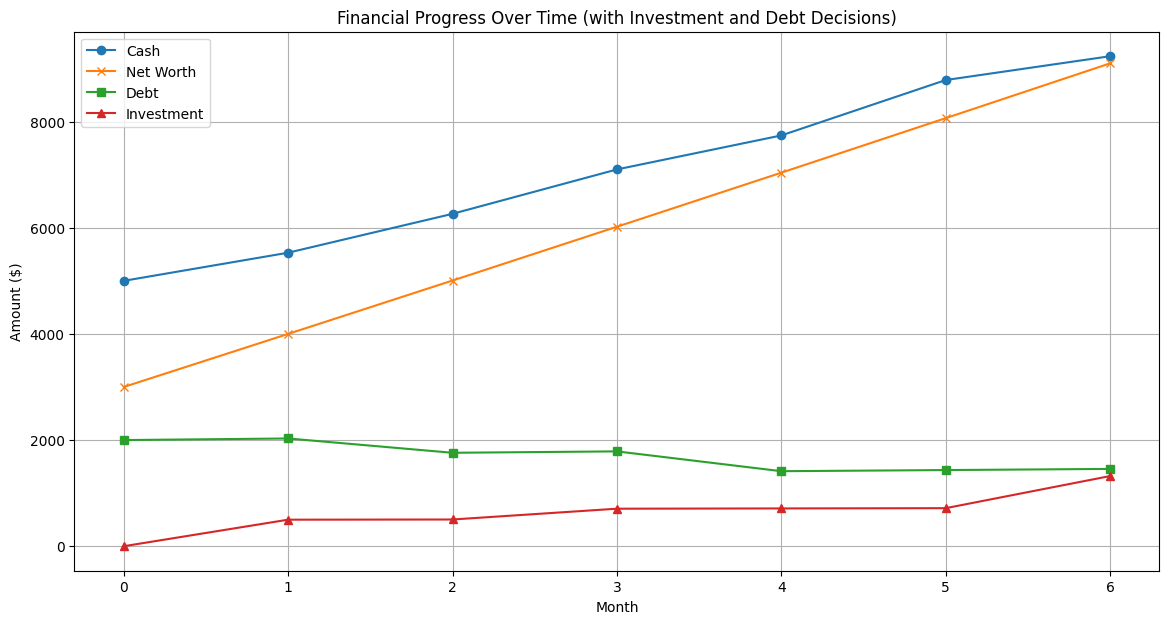

In [12]:
history_df_with_decisions = sim_with_decisions.get_history()

plt.figure(figsize=(14, 7))
plt.plot(history_df_with_decisions['Month'], history_df_with_decisions['Cash'], label='Cash', marker='o')
plt.plot(history_df_with_decisions['Month'], history_df_with_decisions['Net Worth'], label='Net Worth', marker='x')
plt.plot(history_df_with_decisions['Month'], history_df_with_decisions['Debt'], label='Debt', marker='s')
plt.plot(history_df_with_decisions['Month'], history_df_with_decisions['Investment'], label='Investment', marker='^')
plt.title('Financial Progress Over Time (with Investment and Debt Decisions)')
plt.xlabel('Month')
plt.ylabel('Amount ($)')
plt.grid(True)
plt.legend()
plt.show()


As you can see, the new plots now include 'Investment' and 'Net Worth' accurately reflects the impact of investing and paying down debt. The print statements within the `advance_month` method also give immediate feedback on the decisions made each month.

What other features or adjustments would you like to make to the simulator?

### Re-initializing the simulator with interest rates and running for a few months

### Exporting the Dashboard as a Standalone HTML File

Since the Colab menu option isn't available, we'll use `nbconvert` to programmatically export this notebook (which contains your interactive dashboard) to a standalone HTML file.

In [23]:
# Install nbconvert if it's not already installed
!pip install nbconvert

# Get the path to the current notebook
import os
# IMPORTANT: Replace 'YOUR_NOTEBOOK_NAME.ipynb' with the actual name of this Colab notebook file.
# You can find the name at the top of your browser tab or Colab window.
NOTEBOOK_PATH = 'YOUR_NOTEBOOK_NAME.ipynb'

# Save the current notebook state before converting
# This step is crucial to ensure ipywidget states are embedded
from google.colab import drive
# You might need to mount Google Drive if your notebook is saved there, or if you want to save the output there.
# If your notebook is just in the default Colab environment, you might need to save it manually once.

# Run nbconvert to export the notebook to HTML
# The --to html option converts it to HTML.
# The --template lab option includes widget states for interactive widgets.
# The --output option specifies the output filename.
!jupyter nbconvert "{NOTEBOOK_PATH}" --to html --template lab --output "financial_simulator_dashboard.html"

print(f"Notebook exported as financial_simulator_dashboard.html. You can find it in your Colab files browser (left panel) and download it from there.")

[NbConvertApp] WARNING | pattern 'YOUR_NOTEBOOK_NAME.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes=True]
--exec

### Find your notebook's name:

Run the following cell to see a list of files in your current Colab environment. Look for the `.ipynb` file that corresponds to this notebook and use that exact name to replace `'YOUR_NOTEBOOK_NAME.ipynb'` in the `nbconvert` cell above.

In [24]:
!ls

sample_data


In [8]:
# Re-initialize the simulator with new interest rates (e.g., 0.5% monthly savings, 1% monthly debt)
sim_with_interest = FinancialSimulator(
    initial_cash=5000,
    initial_income=3000,
    initial_expenses=2000,
    initial_debt=1000,
    debt_interest_rate=0.01, # 1% monthly debt interest
    savings_interest_rate=0.005 # 0.5% monthly savings interest
)

print("Initial Financial Status (with interest rates):")
sim_with_interest.display_status()

# Advance for a few months with interest
for _ in range(5):
    sim_with_interest.advance_month()


Initial Financial Status (with interest rates):


Metric,Value
Cash,5000.00
Income,3000.00
Expenses,2000.00
Debt,1000.00
Net Worth,4000.00
Debt Interest Rate,0.01
Savings Interest Rate,0.005


--- End of Month 1 ---


Metric,Value
Cash,6030.00
Income,3000.00
Expenses,2000.00
Debt,1010.00
Net Worth,5020.00
Debt Interest Rate,0.01
Savings Interest Rate,0.005


--- End of Month 2 ---


...

Metric,Value
Cash,8105.48
Income,3000.00
Expenses,2000.00
Debt,1030.30
Net Worth,7075.17
Debt Interest Rate,0.01
Savings Interest Rate,0.005


--- End of Month 4 ---


Metric,Value
Cash,9151.00
Income,3000.00
Expenses,2000.00
Debt,1040.60
Net Worth,8110.40
Debt Interest Rate,0.01
Savings Interest Rate,0.005


--- End of Month 5 ---


Metric,Value
Cash,10201.76
Income,3000.00
Expenses,2000.00
Debt,1051.01
Net Worth,9150.75
Debt Interest Rate,0.01
Savings Interest Rate,0.005


### Visualizing the financial history with interest

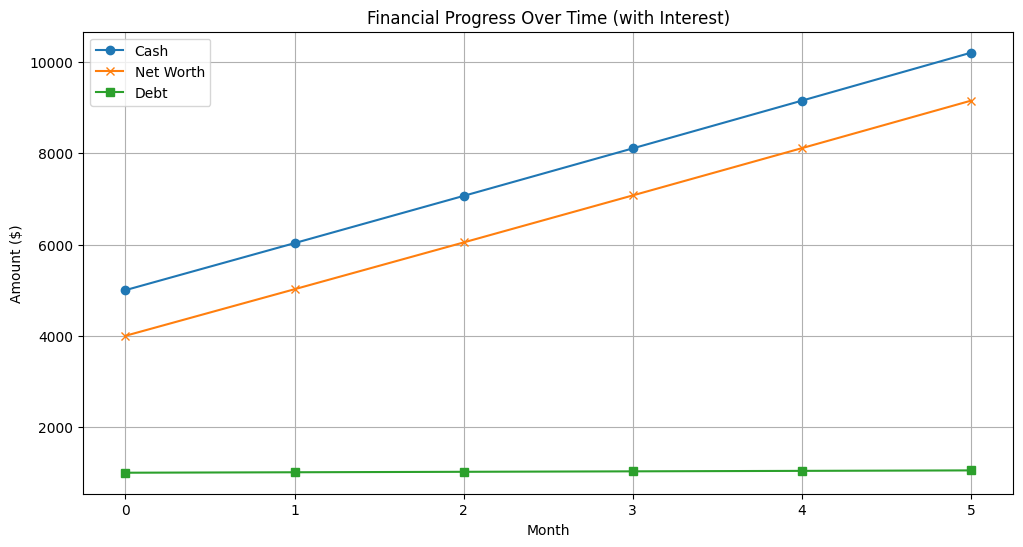

In [9]:
history_df_with_interest = sim_with_interest.get_history()

plt.figure(figsize=(12, 6))
plt.plot(history_df_with_interest['Month'], history_df_with_interest['Cash'], label='Cash', marker='o')
plt.plot(history_df_with_interest['Month'], history_df_with_interest['Net Worth'], label='Net Worth', marker='x')
plt.plot(history_df_with_interest['Month'], history_df_with_interest['Debt'], label='Debt', marker='s')
plt.title('Financial Progress Over Time (with Interest)')
plt.xlabel('Month')
plt.ylabel('Amount ($)')
plt.grid(True)
plt.legend()
plt.show()


Now you can see how the debt and savings interest rates impact the cash and net worth over time. The values in the status table are also formatted to two decimal places for better readability.

What would you like to add next to the simulator?

### Let's create an instance of our simulator and run it for a few months.

In [5]:
# Initialize the simulator
sim = FinancialSimulator(initial_cash=5000, initial_income=3000, initial_expenses=2000, initial_debt=1000)

print("Initial Financial Status:")
sim.display_status()

# Advance for a few months
for _ in range(3):
    sim.advance_month()


Initial Financial Status:


Metric,Value
Cash,5000
Income,3000
Expenses,2000
Debt,1000
Net Worth,4000


--- End of Month 1 ---


Metric,Value
Cash,6000
Income,3000
Expenses,2000
Debt,1000
Net Worth,5000


--- End of Month 2 ---


Metric,Value
Cash,7000
Income,3000
Expenses,2000
Debt,1000
Net Worth,6000


--- End of Month 3 ---


Metric,Value
Cash,8000
Income,3000
Expenses,2000
Debt,1000
Net Worth,7000


### Now, let's visualize the financial history.

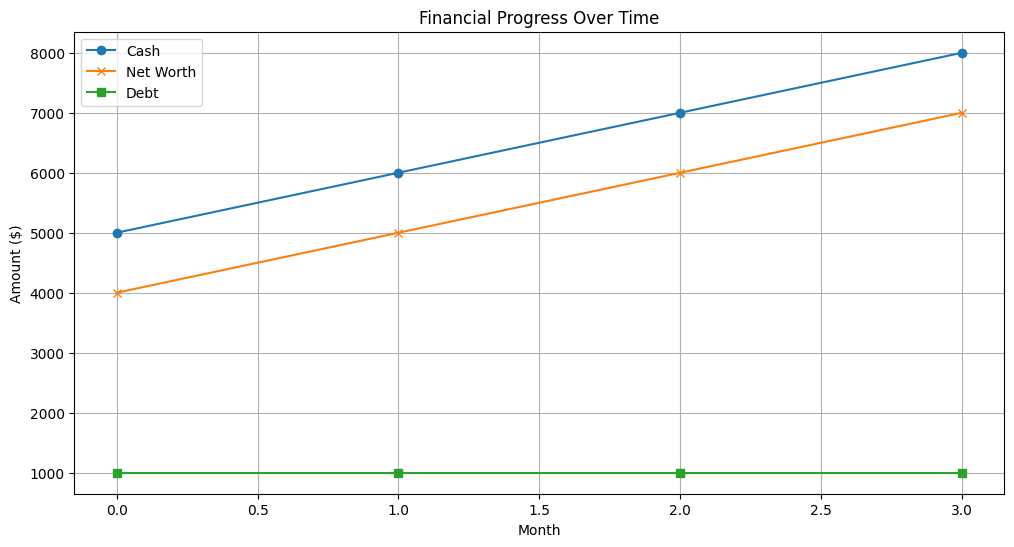

In [6]:
history_df = sim.get_history()

plt.figure(figsize=(12, 6))
plt.plot(history_df['Month'], history_df['Cash'], label='Cash', marker='o')
plt.plot(history_df['Month'], history_df['Net Worth'], label='Net Worth', marker='x')
plt.plot(history_df['Month'], history_df['Debt'], label='Debt', marker='s')
plt.title('Financial Progress Over Time')
plt.xlabel('Month')
plt.ylabel('Amount ($)')
plt.grid(True)
plt.legend()
plt.show()


This is a very basic start. We can add more features like:

*   **Random Events**: Unexpected income, expenses, or investment opportunities.
*   **Decisions**: Allow the user to make choices (e.g., invest, pay down debt, buy a big item).
*   **Interest**: Calculate interest on savings and debt.
*   **Categories**: Break down income and expenses into categories.
*   **Goal Tracking**: Set financial goals and track progress towards them.

What aspect would you like to add or focus on next?